# Setup

In [1]:
import pandas as pd
import duckdb
import numpy as np
import seaborn as sns 
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

from src.charts import compute_conversion_table 
from src.statistical_tests import *

sns.set_theme(style='whitegrid', palette='Set2')

## Utils

In [2]:
def power_regression(df, x_axis, y_axis, ax=None):
    """
        Takes df, x_axis and y_axis \n
        Returns intercept and slope, also draws the chart
    """
    df = df.copy()  

    x = df[x_axis]
    y = df[y_axis]
 
    x_transformed = np.log(x.to_numpy())
    y_transformed = np.log(y.to_numpy())
 
    lr = LinearRegression()
    lr.fit(x_transformed.reshape(-1, 1), y_transformed)
     
    x_range = np.linspace(x.min(), x.max(), 100)
    x_range_transformed = np.log(x_range)
    y_pred_transformed = lr.predict(x_range_transformed.reshape(-1, 1))
    y_pred = np.exp(y_pred_transformed)
 
    slope = lr.coef_[0]
    intercept = np.exp(lr.intercept_) 
    r_squared = lr.score(x_transformed.reshape(-1, 1), y_transformed)

    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f"R2 = % {round(r_squared,4) * 100}") 
 
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_title(f"""{y_axis} = {round(intercept,3)} * ({x_axis} ** {round(slope,3)})""")
    ax.scatter(x, y)
    ax.plot(x_range, y_pred, 'r-')
    ax.set_ylabel(y_axis)
    ax.set_xlabel(x_axis)

    if standalone:
        plt.show()
    
    return intercept, slope, round(r_squared,4) * 100

def perform_data_checks(df):
    
    null_counts = df.isnull().sum()
    if null_counts.sum() == 0:
        print("""
        No missing values found. """)
    else:
        print("""
        Missing values found:""")
        print(null_counts[null_counts > 0])

    
    if df.duplicated().sum() == 0:
        print("""
        No duplicate rows found. """)
    else:
        print("""
        Duplicate rows found. """)

    
    numeric_cols = df.select_dtypes(include=['number'])
    for col in numeric_cols:
        
        threshold = 2
        z_scores = (df[col] - df[col].mean()) / df[col].std()
        outliers = df[abs(z_scores) > threshold]
        if outliers.empty:
            print(f"""
            No outliers found in column '{col}'. """)
        else:
            print(f"""
            Outliers found in column '{col}': """)

def add_date_columns(df, date_col='date'):
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out['year'] = out[date_col].dt.year 
    out["week_year"] = out[date_col].dt.to_period("W")
    out['month_year'] = out[date_col].dt.to_period('M').astype(str)
    out['quarter_year'] = out[date_col].dt.to_period('Q').astype(str)
    return out

def fix_date_column(df, date_col='date', drop_invalid=True, verbose=True):
    out = df.copy()
    raw = out[date_col].astype(str).str.strip()

    # format='mixed' infers per-element, covering both M/D/YY and ISO YYYY-M-D.
    # errors='coerce' -> NaT for anything impossible/unparseable.
    parsed = pd.to_datetime(raw, format='mixed', dayfirst=False, errors='coerce')

    bad_mask = parsed.isna()
    n_bad = int(bad_mask.sum())

    if verbose and n_bad:
        print(f"[fix_date_column] {n_bad} unparseable/impossible date(s) found:")
        print(raw[bad_mask].value_counts().to_string())

    out[date_col] = parsed

    if drop_invalid:
        out = out[~bad_mask].copy()
        if verbose:
            print(f"[fix_date_column] dropped {n_bad} row(s); "
                  f"{len(out)} of {len(df)} rows remain.")

    return out

def clean_data(): 
    
    df_dedups = duckdb.query(f"""
    select 
        date
        , country
        , marketing_channel
        , signups
        , kyc_init	
        , kyc_complete
        , card_activation	
        , first_transaction
    from (
        select *
            , ROW_NUMBER() over(PARTITION by date, country, marketing_channel) as rn 
        from n26_funnel 
    )
    where rn = 1       
""").to_df()
    
    df = fix_date_column(df_dedups, date_col='date', drop_invalid=True, verbose=True)
    return df

def zscore_outlier_scan(df, value_cols, volume_col='signups', sigma=3): 
    flags = pd.DataFrame(index=df.index)
    summary = []

    for c in value_cols:
        z = np.abs(stats.zscore(df[c]))
        is_out = z > sigma
        flags[c] = is_out
        summary.append({
            'column': c,
            'skewness': round(stats.skew(df[c]), 3),   
            'n_outliers': int(is_out.sum()),
            'pct_outliers': round(is_out.mean(), 3),
        })

    out = df.copy()
    out['n_outlier_cols'] = flags.sum(axis=1)

    has_out = out['n_outlier_cols'] > 0
    print(f"Rows flagged in >=1 column (|z|>{sigma}): {has_out.sum()} / {len(out)} = % {round(has_out.sum() / len(out) * 100, 1)} ")
    print(f"  Flagged rows - median {volume_col}: {out.loc[has_out, volume_col].median():.0f}")
    print(f"  Clean rows   - median {volume_col}: {out.loc[~has_out, volume_col].median():.0f}")

    return pd.DataFrame(summary), out

def conversion_table(df, group_by):  
    if group_by: 
        g = df.groupby(group_by)[['signups', 'kyc_init', 'kyc_complete', 'card_activation', 'first_transaction']].sum()
    else:
        g = df[['signups', 'kyc_init', 'kyc_complete', 'card_activation', 'first_transaction']].sum().to_frame().T

    out = pd.DataFrame(index=g.index)
    out['su_kyci_cr']   = g.kyc_init          / g.signups           
    out['kyci_kycc_cr'] = g.kyc_complete      / g.kyc_init         
    out['kycc_card_cr'] = g.card_activation   / g.kyc_complete      
    out['card_ft_cr']   = g.first_transaction / g.card_activation  
    out['su_ft_cr']     = g.first_transaction / g.signups           

    out['su_kyci_dr'] = 1 - out['su_kyci_cr']
    out['kyci_kycc_dr'] = 1 - out['kyci_kycc_cr']
    out['kycc_card_dr'] = 1 - out['kycc_card_cr']
    out['card_ft_dr'] = 1 - out['card_ft_cr']
    out['su_ft_dr'] = 1 - out['su_ft_cr']

    out = out.join(g)  
 
    return out.reset_index()

def plot_kde(df, aggregation_level="month_year", rate_type = "conversion"):
    unique_aggregates = df[aggregation_level].unique()
    if aggregation_level == "month_year":
        rows, cols = 9, 4
    elif aggregation_level == "quarter_year":
        rows, cols = 4, 3
    elif aggregation_level == "year":
        rows, cols = 1, 3 
    else:
        raise ValueError("Invalid aggregation level. Choose from 'month_year', 'quarter_year', or 'year'.")

    fig, axes = plt.subplots(rows, cols, figsize=(15, 8), constrained_layout=True)
    axes = axes.flatten()
    
    for i, aggregate in enumerate(unique_aggregates):
        subset = df[df[aggregation_level] == aggregate]
        ax = axes[i]
        if rate_type == "conversion":
            sns.kdeplot(data=subset, x="su_kyci_cr", label="su_kyci_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_cr", label="kyci_kycc_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_cr", label="kycc_card_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_cr", label="card_ft_cr", fill=True, ax=ax)
        else:
            sns.kdeplot(data=subset, x="su_kyci_dr", label="su_kyci_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_dr", label="kyci_kycc_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_dr", label="kycc_card_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_dr", label="card_ft_dr", fill=True, ax=ax)
        ax.set_title(f"{aggregate}")
        ax.set_xlabel("")
        ax.legend()

    for j in range(len(unique_aggregates), len(axes)):
        axes[j].axis("off")

    plt.show()

## Task 1: Funnel Performance & Channel Effectiveness
 
### Read on the data first

Before comparing channels, I want to be clear about what this dataset is, because it changes how every question that follows should be interpreted.

The acquisition funnel is *engineered* to be flat. Conversion is almost identical across every channel, every country, and every month throughout the three-year period. That is not how acquisition works in production. So my goal is not to announce a winner from statistical noise, and say channel X is the best because it's performing ~0.5% (arbitrary number here) better. My goal is to demonstrate that the given funnel is intentionally flat, then answer the business questions the same way I would if this were real production data while being explicit about what the dataset cannot tell us.

One test is enough to establish that. I aggregated signups and first transactions at channel level and ran a chi-square test of channel versus first-transaction conversion. With over 1 million signups, the test has enormous statistical power. At this sample size, even the tiniest conversion gap would almost certainly be detected. 

The results showed that the channels are not just *similar*, but they are statistically indistinguishable from one another. 

### Q1: Consolidated funnel, and what "channel effectiveness" should actually measure
 
**Plan** 

First I build the funnel from raw counts at the correct granularity, then I decide which metrics belong to the question. 

The granularity of the data should be on date-country-channel. and for deduplication, even though this approach might be up to a challenge, I chose to keep the first occurance instead of summing or dropping them because the duplicated rows were not exactly same for many examples, but very close ones. so, I chose to accept them as data quality issues; not something to be aggregated.

Then I separate the two kinds of "effectiveness" metric, the ones that diagnose the funnel and the ones that justify the investment, because the question in this case-study treats them as one and they are not.

In [3]:
n26_funnel = pd.read_csv("../data/part_a_dataset.csv")

df = clean_data()
df = add_date_columns(df, date_col='date')

perform_data_checks(df)

[fix_date_column] 70 unparseable/impossible date(s) found:
date
2019-2-29    14
2017-2-29    13
2018-2-29    13
2019-2-30    11
2017-2-30    10
2018-2-30     9
[fix_date_column] dropped 70 row(s); 12094 of 12164 rows remain.

        No missing values found. 

        No duplicate rows found. 

            No outliers found in column 'signups'. 

            No outliers found in column 'kyc_init'. 

            No outliers found in column 'kyc_complete'. 

            No outliers found in column 'card_activation'. 

            No outliers found in column 'first_transaction'. 

            No outliers found in column 'year'. 


In [4]:
df[["signups","kyc_init","kyc_complete","card_activation","first_transaction"]].describe()

,signups,kyc_init,kyc_complete,card_activation,first_transaction
count,12094.000000,12094.000000,12094.000000,12094.000000,12094.000000
mean,95.020506,75.009426,54.950141,45.055234,34.960972
std,3.173853,3.179398,3.169969,3.173673,3.160232
min,90.000000,70.000000,50.000000,40.000000,30.000000
25%,92.000000,72.000000,52.000000,42.000000,32.000000
50%,95.000000,75.000000,55.000000,45.000000,35.000000
75%,98.000000,78.000000,58.000000,48.000000,38.000000
max,100.000000,80.000000,60.000000,50.000000,40.000000


In [5]:
compute_conversion_table(df)

,Stage,Volume,% of Signup,% of Previous,Drop-off,Drop-off % of Previous,Drop-off % of Signup
0,Signup,1149178,1.000000,100.000000,NaN,NaN,NaN
1,KYC Initiated,907164,0.789403,0.789403,242014.0,0.210597,0.210597
2,KYC Completed,664567,0.578298,0.732576,242597.0,0.267424,0.421702
3,Card Activated,544898,0.474163,0.819929,119669.0,0.180071,0.525837
4,First Transaction,422818,0.367931,0.775958,122080.0,0.224042,0.632069


**Answer** 

Aggregated across the full dataset, the funnel reads:
 
| Step | Conversion | Drop |
|---|---|---|
| Signup to KYC init | 78.9% | 21.1% |
| KYC init to KYC complete | **73.3%** | **26.7%** |
| KYC complete to Card activation | 82.0% | 18.0% |
| Card activation to First transaction | 77.6% | 22.4% |
| **Signup to First transaction** | **36.8%** | **63.2%** |
 
End to end, 36.8% of signups reach a first transaction. The interactive version is the Streamlit app(**https://n26case-korcankomili.streamlit.app/**), with sidebar filters, a breakdown toggle, and an expandable step table. 

The consolidated view and any channel or country cut come from the same `conversion_table()` function, so the numbers reconcile across views.
 
On metrics: step conversion and step drop-off are the right _diagnostic_ measures. They tell me where the drop is in the funnel. They are the wrong measure for an investment decision, because they say nothing about what a channel costs or what it returns. For "where do we put the next euro," the metric I would use LTV/CAC, with CAC built from spend and LTV from downstream revenue or retention. Neither input exists in this dataset. There is no spend column, so no CAC. There is no revenue or LTV, so no ROI(ROAS). Without those I cannot rank channels on efficiency, and I cannot build an MMM to find where the marginal euro pays off.
 
The funnel tells me how users move. It does not tell me which users are worth acquiring or what they cost, and that gap drives every channel answer below.

### Q2: Step-level and channel comparison: where the gaps are, and the anomalies
 
**Plan** 

I compare each step and the full funnel across all 11 channels, then I test whether the differences I see are real or sampling noise. 

A raw spread is not enough on its own, so I check three things: the effect size behind the spread, the stability of conversion over time, and whether the row-level "outliers" carry any signal. If all three point the same way, then we can confidently say that we are moving in the right direction. 

In [6]:
mc_cr = conversion_table(df, group_by="marketing_channel")
mc_cr[["marketing_channel", 'su_kyci_cr', 'kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr','su_ft_cr']]

,marketing_channel,su_kyci_cr,kyci_kycc_cr,kycc_card_cr,card_ft_cr,su_ft_cr
0,affiliate,0.788893,0.733642,0.819864,0.776557,0.368483
1,app store,0.787312,0.733419,0.820180,0.778148,0.368528
2,brand influencer,0.788822,0.736505,0.812455,0.770590,0.363728
3,direct,0.790224,0.732304,0.817703,0.778428,0.368345
4,display,0.789215,0.732252,0.819521,0.773876,0.366511
5,friend referral,0.790195,0.730556,0.824720,0.771135,0.367134
6,organic search,0.790732,0.730653,0.822859,0.777625,0.369688
7,other organic,0.789659,0.733426,0.815918,0.775873,0.366634
8,paid search,0.788504,0.732809,0.819404,0.779282,0.368967
9,paid social,0.789184,0.733575,0.820057,0.771199,0.366128


In [7]:
c_cr = conversion_table(df, group_by="country")
c_cr[["country", 'su_kyci_cr', 'kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr','su_ft_cr']]

,country,su_kyci_cr,kyci_kycc_cr,kycc_card_cr,card_ft_cr,su_ft_cr
0,BEL,0.788515,0.733517,0.818890,0.775440,0.367277
1,DEU,0.791450,0.730672,0.819819,0.775358,0.367592
2,ESP,0.788198,0.732291,0.822098,0.772415,0.366516
3,EST,0.790519,0.730799,0.824663,0.771799,0.367698
4,FRA,0.787715,0.735511,0.820032,0.775002,0.368207
5,GRC,0.788660,0.733286,0.819100,0.782673,0.370750
6,IRL,0.789126,0.733351,0.816830,0.779204,0.368334
7,ITA,0.789306,0.733800,0.817337,0.780142,0.369316
8,NOR,0.793404,0.728436,0.819094,0.771259,0.365107
9,POL,0.792443,0.732016,0.819011,0.776832,0.369067


In [8]:
_COUNTS = ["signups", "kyc_init", "kyc_complete", "card_activation", "first_transaction"]

_FUNNEL_STEPS = [
    ("su_kyci",   "signups",          "kyc_init"),
    ("kyci_kycc", "kyc_init",         "kyc_complete"),
    ("kycc_card", "kyc_complete",     "card_activation"),
    ("card_ft",   "card_activation",  "first_transaction"),
    ("su_ft",     "signups",          "first_transaction"),
]

chi2_by_step(df = df, group_col = "marketing_channel", counts = _COUNTS, steps = _FUNNEL_STEPS)

,step,n,chi2,dof,p,cohens_w,band
0,su_kyci,1149178,7.14,10,0.712,0.0025,negligible
1,kyci_kycc,907164,7.56,10,0.672,0.0029,negligible
2,kycc_card,664567,33.37,10,0.000,0.0071,negligible
3,card_ft,544898,28.67,10,0.001,0.0073,negligible
4,su_ft,1149178,9.58,10,0.478,0.0029,negligible


In [9]:
chi2_by_step(df = df, group_col = ["country", "marketing_channel"], counts = _COUNTS, steps = _FUNNEL_STEPS)

,step,n,chi2,dof,p,cohens_w,band
0,su_kyci,1149178,108.75,127,0.878,0.0097,negligible
1,kyci_kycc,907164,116.90,127,0.729,0.0114,negligible
2,kycc_card,664567,230.69,127,0.000,0.0186,negligible
3,card_ft,544898,321.24,127,0.000,0.0243,negligible
4,su_ft,1149178,86.30,127,0.998,0.0087,negligible


In [10]:
chi2_by_step(df = df, group_col = ["country", "quarter_year"], counts = _COUNTS, steps = _FUNNEL_STEPS)

,step,n,chi2,dof,p,cohens_w,band
0,su_kyci,1149178,136.56,143,0.636,0.0109,negligible
1,kyci_kycc,907164,129.92,143,0.776,0.0120,negligible
2,kycc_card,664567,278.93,143,0.000,0.0205,negligible
3,card_ft,544898,265.74,143,0.000,0.0221,negligible
4,su_ft,1149178,86.24,143,1.000,0.0087,negligible


In [11]:
chi2_by_step(df = df, group_col = ["marketing_channel", "quarter_year"], counts = _COUNTS, steps = _FUNNEL_STEPS)

,step,n,chi2,dof,p,cohens_w,band
0,su_kyci,1149178,140.95,131,0.261,0.0111,negligible
1,kyci_kycc,907164,144.21,131,0.203,0.0126,negligible
2,kycc_card,664567,283.39,131,0.000,0.0207,negligible
3,card_ft,544898,275.33,131,0.000,0.0225,negligible
4,su_ft,1149178,84.79,131,0.999,0.0086,negligible


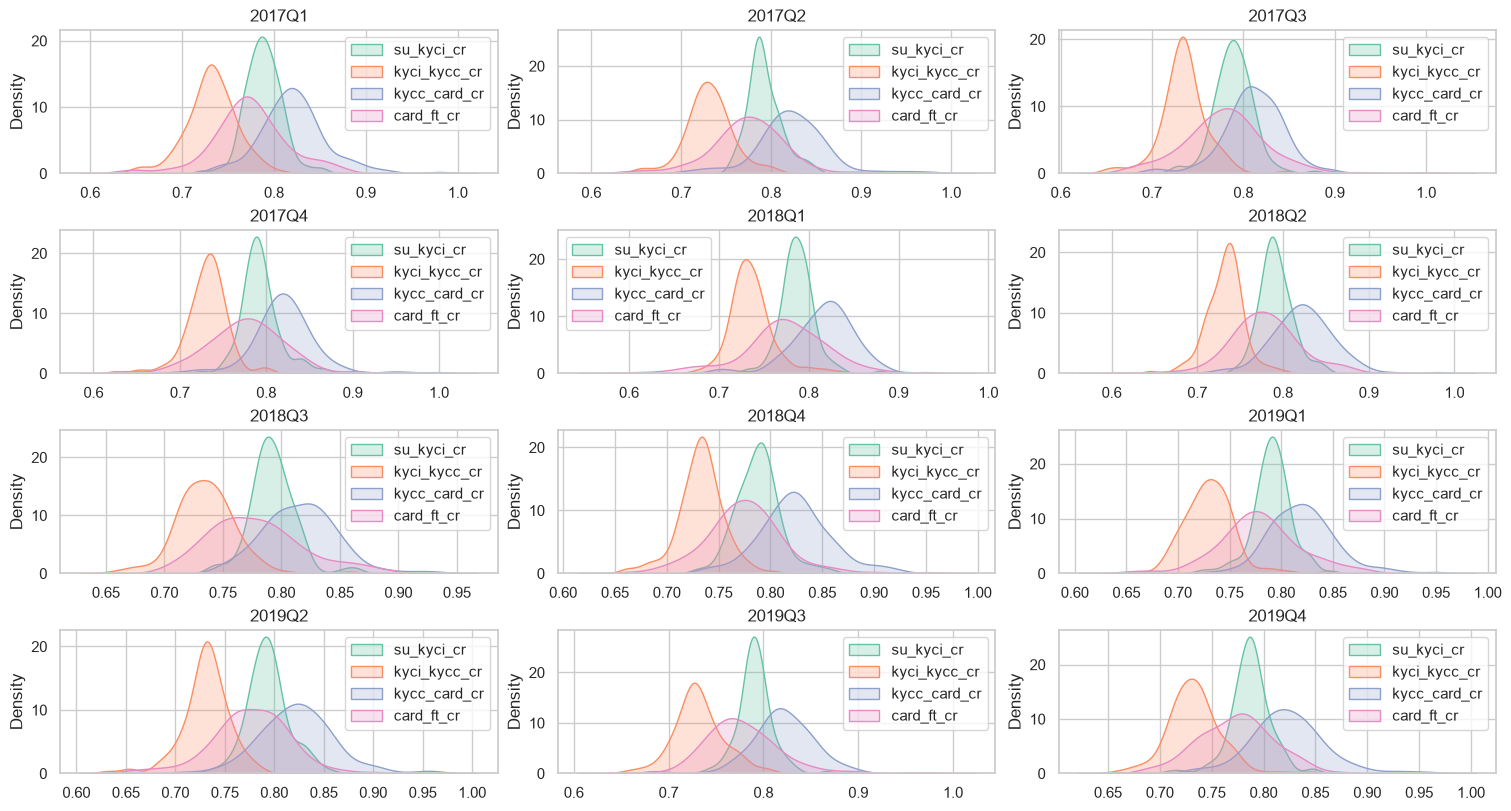

In [12]:
ct_monthly = conversion_table(df, group_by=["month_year", "marketing_channel", "country"])
ct_quarterly = conversion_table(df, group_by=["quarter_year", "marketing_channel", "country"])


plot_kde(ct_quarterly, aggregation_level="quarter_year")

In [13]:
print(f"{round(ct_quarterly["su_ft_cr"].std() * 100, 2)} %")

1.71 %


In [14]:
m2_summary, m2_outlier = zscore_outlier_scan(df = ct_monthly,
                                           value_cols = ['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr'],
                                           sigma=2)


m2_summary

Rows flagged in >=1 column (|z|>2): 774 / 3835 = % 20.2 
  Flagged rows - median signups: 98
  Clean rows   - median signups: 291


,column,skewness,n_outliers,pct_outliers
0,su_kyci_cr,0.156,243,0.063
1,kyci_kycc_cr,0.134,215,0.056
2,kycc_card_cr,0.239,229,0.060
3,card_ft_cr,0.210,237,0.062
4,su_ft_cr,0.035,222,0.058


In [15]:
m3_summary, m3_outlier = zscore_outlier_scan(df = ct_monthly,
                                           value_cols = ['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr'],
                                           sigma=3)

m3_summary

Rows flagged in >=1 column (|z|>3): 120 / 3835 = % 3.1 
  Flagged rows - median signups: 94
  Clean rows   - median signups: 285


,column,skewness,n_outliers,pct_outliers
0,su_kyci_cr,0.156,31,0.008
1,kyci_kycc_cr,0.134,34,0.009
2,kycc_card_cr,0.239,30,0.008
3,card_ft_cr,0.210,26,0.007
4,su_ft_cr,0.035,10,0.003


**Answer** 

Every cut tells the same story. The weakest step across the whole funnel is KYC init to KYC complete at ~73%, the single biggest leak, and that ordering never changes by channel or country. Across channels, full-funnel conversion runs from 36.4% (brand influencer) to 37.1% (partnership), a spread of 0.71 percentage points, and every individual step sits within roughly one point across all 11 channels.
 
The spread is noise, not signal. The chi-square from the lead already shows no detectable channel effect even at 1.15M signups (negligible on all five funnel steps). Over 36 months the full-funnel rate has a standard deviation of 1.71%, which is a flat line rather than a trend.

The row-level conversion distribution is symmetric and tight (skew ≈ 0.035 for end-to-end rate): a z-score cut at 3 SD flags 120 rows (3.1%), and loosening to 2 SD flags 774 rows (20.2%). both groups have a lower median signup count (94 vs 285 at 3 SD; 98 vs 291 at 2 SD), confirming this is small-denominator variance from low-volume rows, not a real performance difference.
 
**The anomaly worth naming is this flatness itself.** Real channels acquire different cohorts. Paid traffic converts differently from organic, referred users behave differently from display. Identical step conversion across paid, organic, referral, and influencer is not something you see in production, and it is the clearest fingerprint that this data is synthetic.
 
The channels are not even close, but same, and the only real variation left in this data is __volume__.

### Q3: Which channels to recommend for First Transaction

**Plan**

Since step-level conversion is already surreally established as uniform, volume is the only remaining axis to compare across channels. I check the signup distribution to see whether it offers any meaningful differentiation.

I also separate what this dataset can support from what a complete recommendation would actually require. they're different answers.

**Answer**

Conversion is identical across all 11 channels (~36.8% end-to-end), so the only differentiator this dataset offers is signup volume. Every channel or country converts at the same rate, which means more signups directly produces more first transactions. Volume ranges from 24.9k (brand influencer) to 146.5k (other organic), roughly a 6x spread, so scaling the highest-volume channels is the only defensible recommendation with the given dataset.

**That said, volume without cost data doesn't tell us anything in real life**. The highest-volume channel could easily have the worst LTV/CAC. Before taking this to a budget conversation, I'd need spend per channel to calculate CAC, LTV per user to assess return, and upper-funnel metrics like impressions and clicks to understand where marginal investment actually pays off. None of that exists here.

On this dataset: prioritize volume. 
On real data: I wouldn't make a channel investment recommendation without LTV/CAC.

### Q4: Efficiency vs. scale trade-off
 
**Plan** 

The trade-off question is really a plot: full-funnel conversion against signup volume, looking for the channels that lose efficiency as they scale. Also, checking the power-law regressions, expecting diminishing returns, for each channel will help us to understand if there's any scale trade-offs within channels.

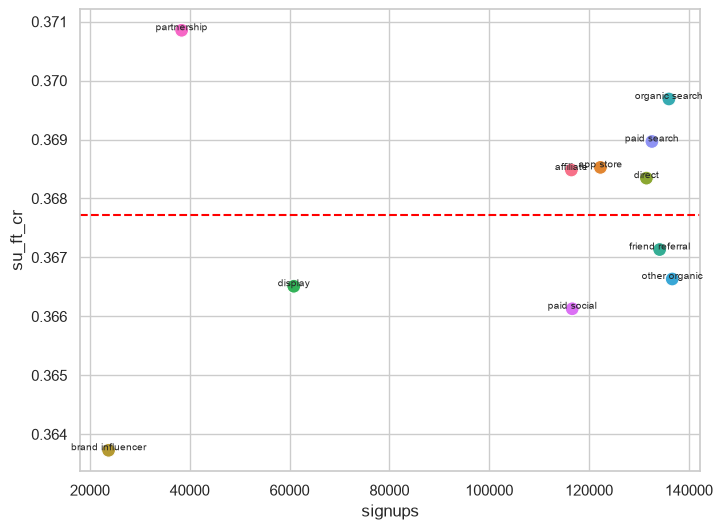

In [16]:
avg_su_ft_cr = mc_cr["su_ft_cr"].mean()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=mc_cr, x="signups", y="su_ft_cr", hue="marketing_channel", s=100, legend=False)
for i in range(len(mc_cr)):
    plt.text(mc_cr["signups"][i], mc_cr["su_ft_cr"][i], mc_cr["marketing_channel"][i], fontsize=7, ha='center')
plt.axhline(avg_su_ft_cr, color="red", linestyle="--", label=f"Avg su_ft_cr: {avg_su_ft_cr:.2f}")
plt.show()

Slope: 1.0032817166019818
Intercept: 0.35706009050858795
R2 = % 99.95


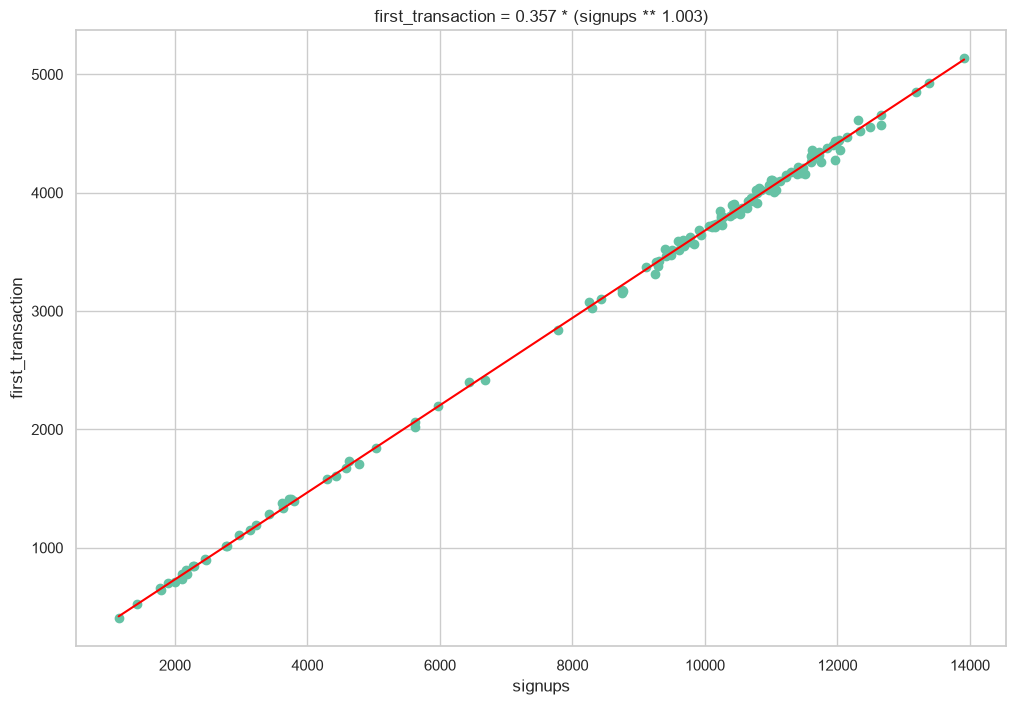

In [17]:
data = df.groupby(['marketing_channel', 'quarter_year'])[['signups', 'first_transaction']].sum().reset_index()
intercept, slope, r2 = power_regression(data, x_axis='signups', y_axis='first_transaction')

Slope: 0.9906858060642432
Intercept: 0.39725910444901424
R2 = % 98.25
Slope: 0.9996664499493251
Intercept: 0.3694717582661937
R2 = % 98.08
Slope: 1.0085598980663115
Intercept: 0.34385848875417263
R2 = % 98.97
Slope: 0.9676939563871215
Intercept: 0.48028267024094484
R2 = % 99.53999999999999
Slope: 1.0087689101862458
Intercept: 0.3432095936786855
R2 = % 99.42999999999999
Slope: 1.0337748343051112
Intercept: 0.2779663344185322
R2 = % 99.45
Slope: 1.0048863425399777
Intercept: 0.35501994450662755
R2 = % 99.11999999999999
Slope: 0.989080067993549
Intercept: 0.40114416482687737
R2 = % 98.31
Slope: 0.9715310458548597
Intercept: 0.46619620481769003
R2 = % 98.67
Slope: 0.9935684414594588
Intercept: 0.3856208357004223
R2 = % 99.16
Slope: 1.0206226317819482
Intercept: 0.32077216269625813
R2 = % 99.36


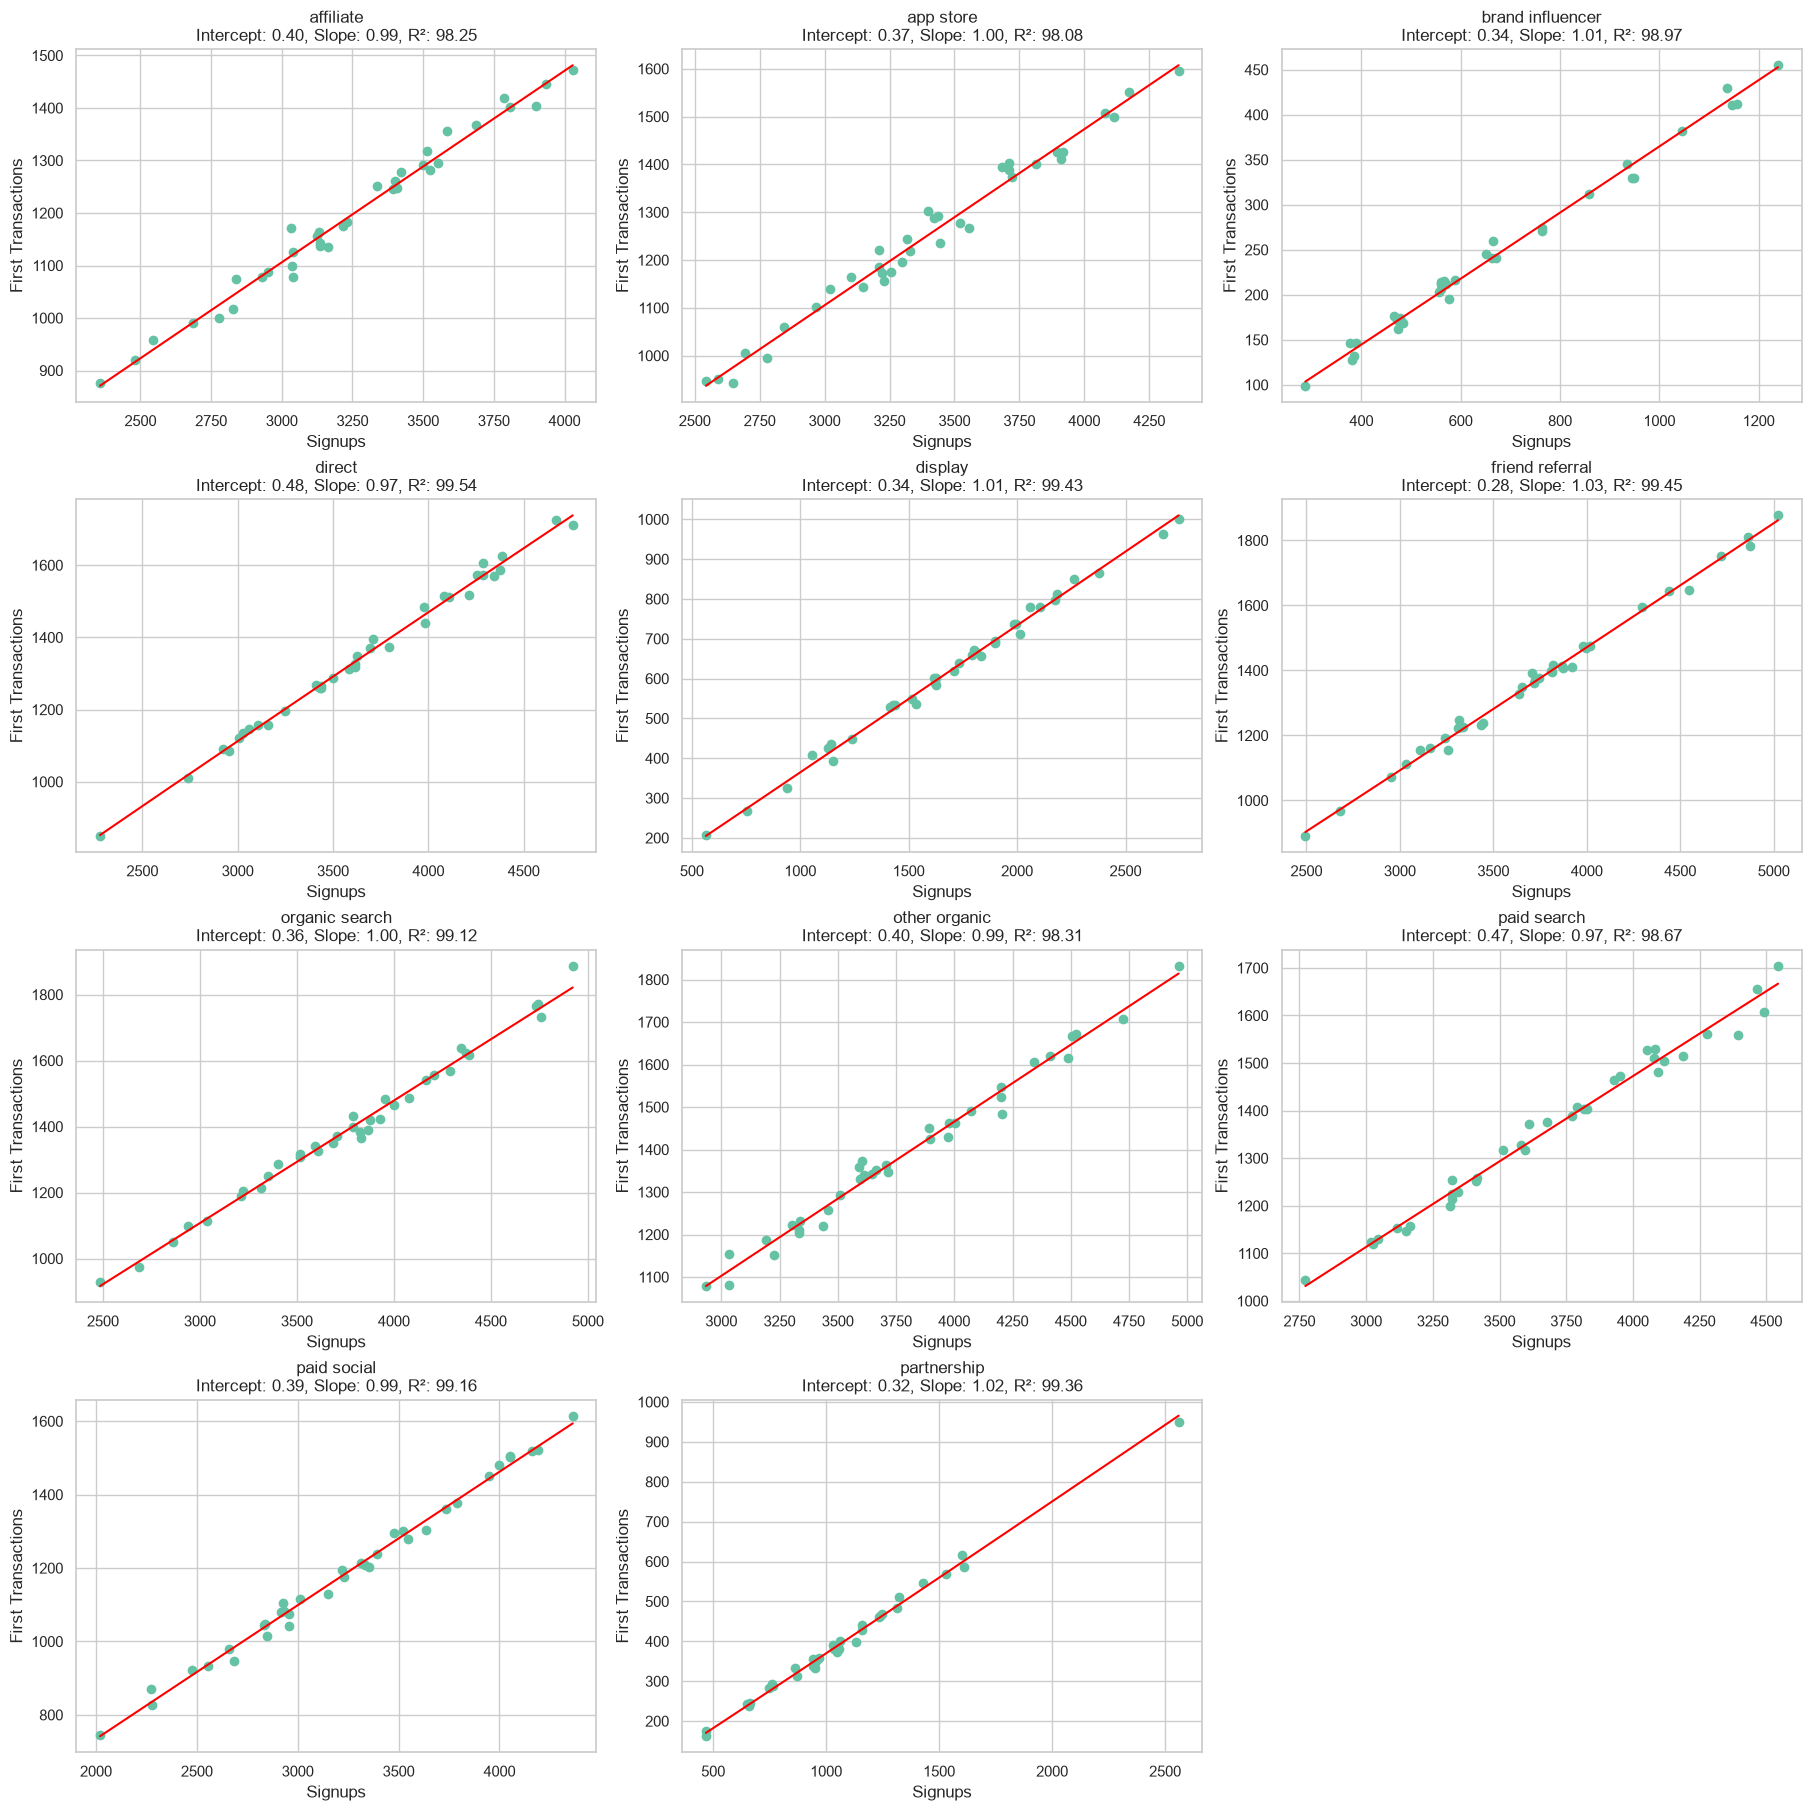

In [18]:
grouped_data = df.groupby(['marketing_channel', 'month_year'])[['signups', 'first_transaction']].sum().reset_index()
 
results = {}
 
fig, axes = plt.subplots(4, 3, figsize=(18, 18), constrained_layout=True)
axes = axes.flatten()

for idx, (channel, data) in enumerate(grouped_data.groupby('marketing_channel')):
    ax = axes[idx]
    intercept, slope, r2 = power_regression(data, x_axis='signups', y_axis='first_transaction', ax=ax)
    results[channel] = {'intercept': intercept, 'slope': slope, 'r2': r2}
    ax.set_title(f"{channel}\nIntercept: {intercept:.2f}, Slope: {slope:.2f}, R²: {r2:.2f}")
    ax.set_xlabel('Signups')
    ax.set_ylabel('First Transactions')

for idx in range(len(grouped_data['marketing_channel'].unique()), len(axes)):
    axes[idx].axis('off')

plt.show()

In [19]:
pd.DataFrame(results).T

,intercept,slope,r2
affiliate,0.397259,0.990686,98.25
app store,0.369472,0.999666,98.08
brand influencer,0.343858,1.008560,98.97
direct,0.480283,0.967694,99.54
display,0.343210,1.008769,99.43
friend referral,0.277966,1.033775,99.45
organic search,0.355020,1.004886,99.12
other organic,0.401144,0.989080,98.31
paid search,0.466196,0.971531,98.67
paid social,0.385621,0.993568,99.16


**Answer** 

There is no difference in scaling efficiency at all, and that **absence is the finding**. The nightmare of a data scientist: R2 is 1 :) Another issue is that we see >1 slopes for almost 50% of the channels, indicating that the problem we are trying to solve is not even concave, which I highly doubt. 

Normally the high-volume channels convert a little worse, because they reach broader and colder audiences, and that tension is the whole point of the efficiency-versus-scale question. Here the plot is a flat band. The spread between the best and worst channel is (0.007) points, well under one point, with no relationship to volume.
 
On real data this is where it gets interesting. You would plot CAC or LTV/CAC against volume, find the channels that hold efficiency as they scale, and watch for the point where more budget starts dragging conversion down. That curve tells you how far each channel can scale before it stops paying off, and none of its inputs are in this dataset.